In [1]:
!apt-get install openjdk-11-jdk-headless -qq
!pip install -q pyspark findspark

In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
# No need to download Spark—pip installation includes Spark JARs

import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ColabSpark").getOrCreate()
spark

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[Loaded] Rows=25,403, Columns=39
[OK] Rebuilt PAIN_2A_REBUILT from columns: ['PAIN_2A_ohe_1']
[WARN] No one-hot columns found for TIRED_1


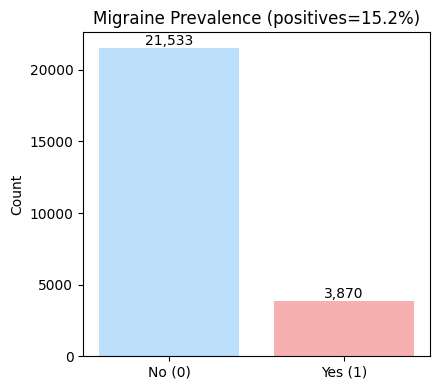

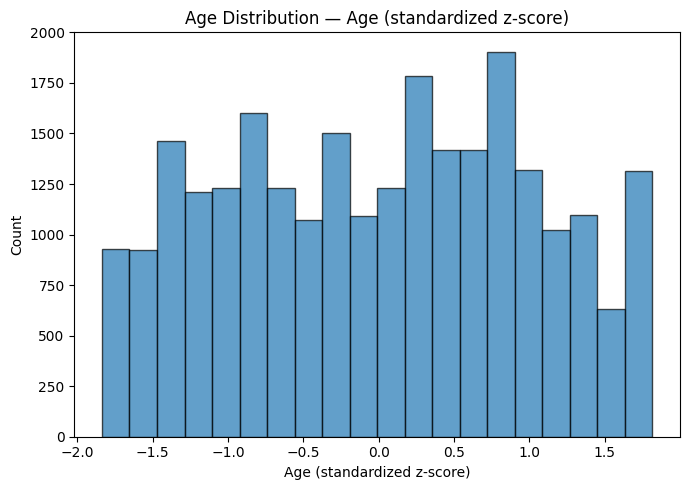

+---------------+-----+
|PAIN_2A_REBUILT|count|
+---------------+-----+
|           NULL|16535|
|              1| 8868|
+---------------+-----+



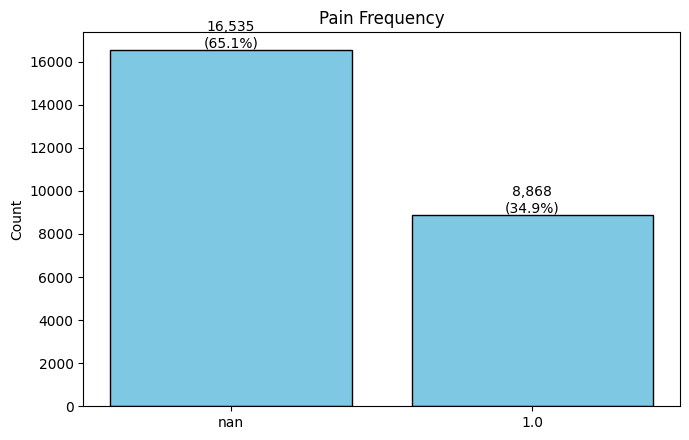

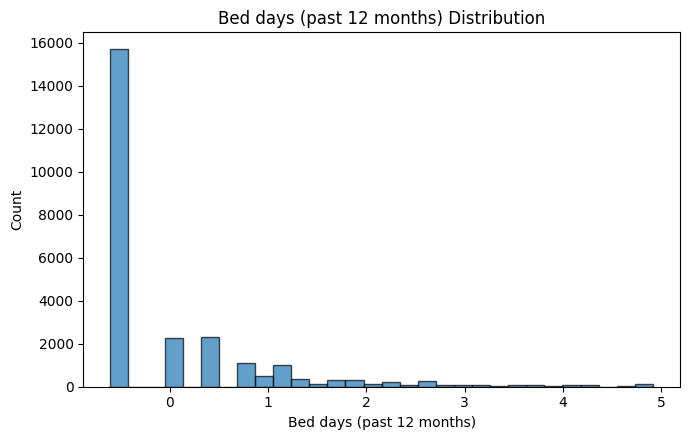

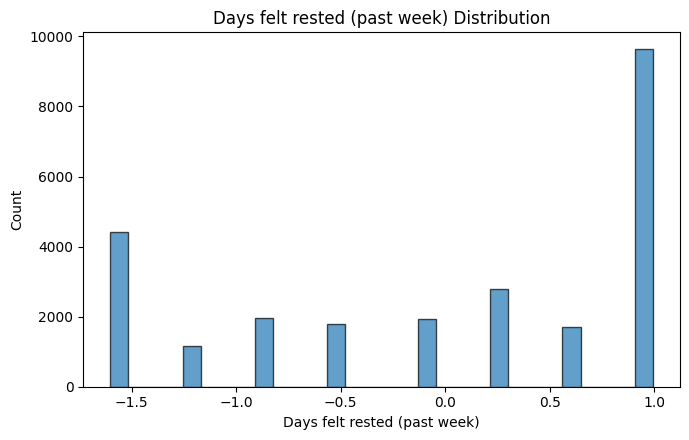

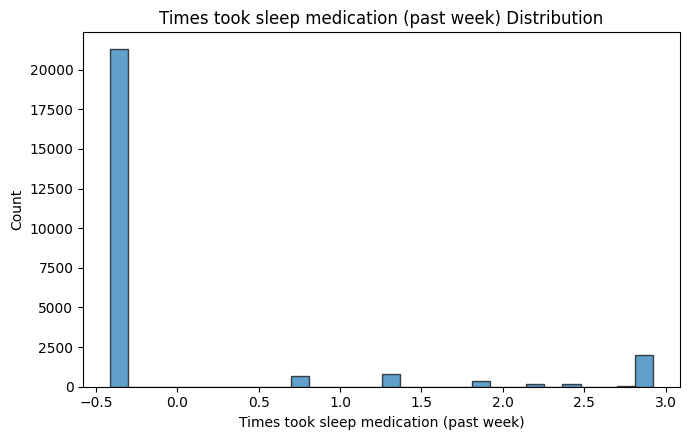

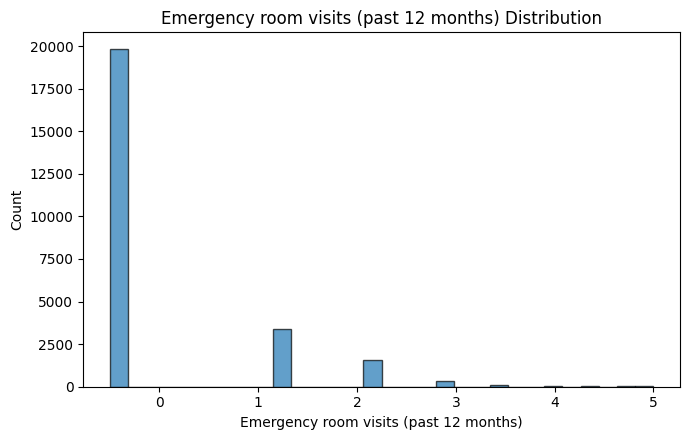

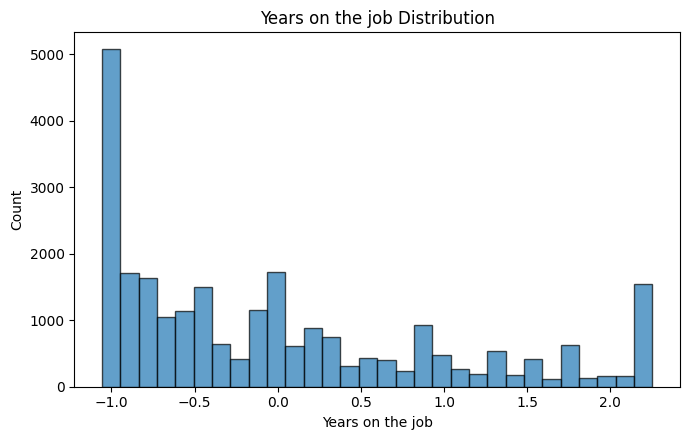

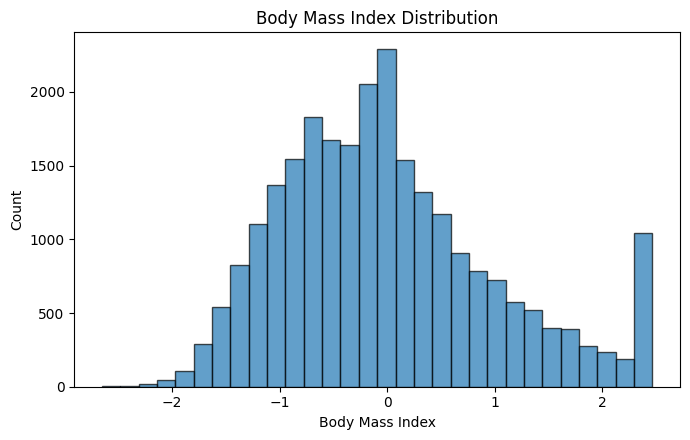

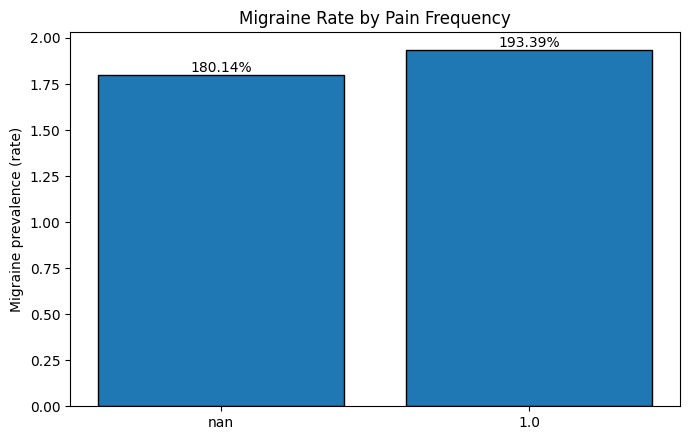

[OK] Using mental health variable: MENTAL_HEALTH_SCORE


/tmp/ipython-input-3599173913.py:206: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


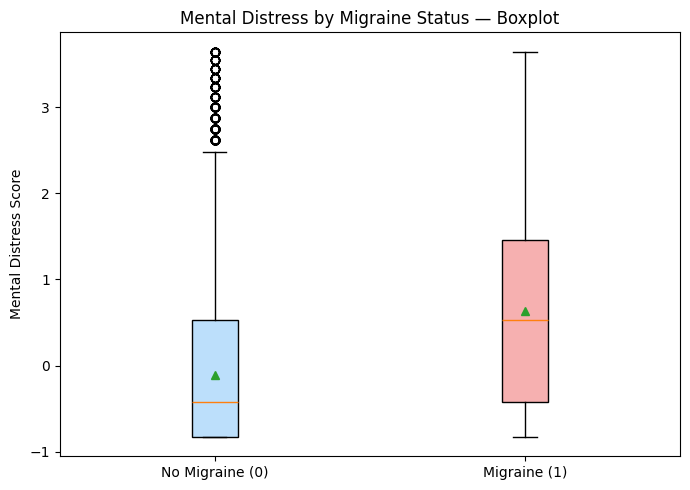

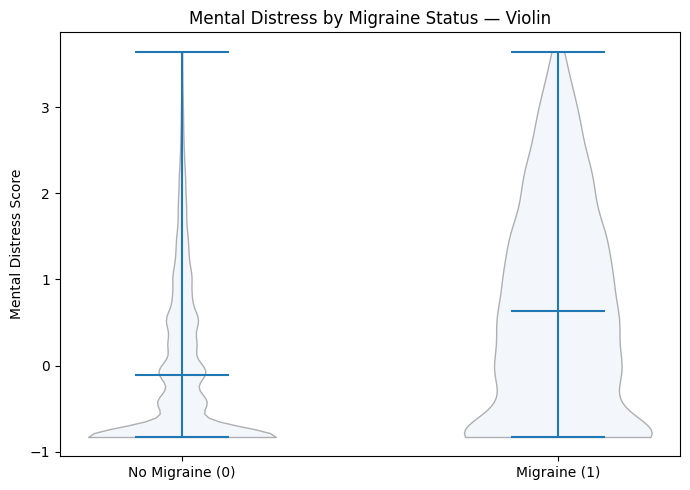


✅ All figures saved to /content/drive/MyDrive/Infosys722/iteration4_prep_outputs/figs


In [7]:
# ============================================================
# 8.2 Visualisation — Full PySpark Version (Iteration 4)
# Author: Tonia
# ============================================================

from pyspark.sql import SparkSession, functions as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

spark = SparkSession.builder.getOrCreate()

# ---------- 路径 ----------
BASE = "/content/drive/MyDrive/Infosys722/iteration4_prep_outputs"
FIG_DIR = f"{BASE}/figs"
os.makedirs(FIG_DIR, exist_ok=True)

# ---------- 读入数据 ----------
df = spark.read.parquet(f"{BASE}/final_selected_table.parquet")
print(f"[Loaded] Rows={df.count():,}, Columns={len(df.columns)}")

# ============================================================
# Helper: rebuild categorical from one-hot columns (auto-detect)
# ============================================================
def rebuild_category(df, base):
    import re
    cols = [c for c in df.columns if re.match(fr"^{base}(_ohe)?_\d+$", c)]
    if not cols:
        print(f"[WARN] No one-hot columns found for {base}")
        return df
    df = df.withColumn(f"{base}_REBUILT", F.lit(None).cast("int"))
    for c in cols:
        lv = int(re.findall(r"(\d+)$", c)[0])
        df = df.withColumn(
            f"{base}_REBUILT",
            F.when(F.col(c) == 1, F.lit(lv)).otherwise(F.col(f"{base}_REBUILT"))
        )
    print(f"[OK] Rebuilt {base}_REBUILT from columns: {cols}")
    return df

df = rebuild_category(df, "PAIN_2A")
df = rebuild_category(df, "TIRED_1")

# ============================================================
# 1. Migraine prevalence
# ============================================================
if "AMIGR" in df.columns:
    prev = df.groupBy("AMIGR").count().toPandas().sort_values("AMIGR")
    total = prev["count"].sum()
    pos = prev.loc[prev["AMIGR"]==1,"count"].iloc[0]
    pos_rate = pos / total

    plt.figure(figsize=(4.5,4))
    plt.bar(["No (0)", "Yes (1)"], [total-pos, pos], color=["#bcdffb","#f6b0b0"])
    plt.title(f"Migraine Prevalence (positives={pos_rate:.1%})")
    plt.ylabel("Count")
    for i,v in enumerate([total-pos, pos]):
        plt.text(i, v, f"{int(v):,}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/fig_8_10_target_prevalence.png", dpi=250)
    plt.show()

# ============================================================
# 2. Age distributions
# ============================================================
for col in ["AGE_P_ORIG", "AGE_P"]:
    if col in df.columns:
        vals = df.select(col).dropna().toPandas()[col]
        plt.figure(figsize=(7,5))
        plt.hist(vals, bins=20, edgecolor="black", alpha=0.7)
        xlabel = "Age (years)" if col=="AGE_P_ORIG" else "Age (standardized z-score)"
        plt.xlabel(xlabel)
        plt.ylabel("Count")
        plt.title(f"Age Distribution — {xlabel}")
        plt.tight_layout()
        plt.savefig(f"{FIG_DIR}/fig_8_11_{col.lower()}_distribution.png", dpi=250)
        plt.show()

# ============================================================
# Pain & Tiredness frequency distributions
# ============================================================
for var, title, fname, color in [
    ("PAIN_2A_REBUILT", "Pain Frequency", "fig_8_12_pain2a_distribution.png", "#7ec8e3"),
    ("TIRED_1_REBUILT", "Tiredness Frequency", "fig_8_13_tired1_distribution.png", "#a3d5a7")
]:
    if var in df.columns:
        tmp = df.groupBy(var).count().orderBy(var)
        tmp.show()  #
        counts = tmp.toPandas()
        plt.figure(figsize=(7,4.5))
        plt.bar(counts[var].astype(str), counts["count"], color=color, edgecolor="black")
        plt.ylabel("Count")
        plt.title(title)
        total = counts["count"].sum()
        for i,v in enumerate(counts["count"]):
            plt.text(i, v, f"{v:,}\n({v/total*100:.1f}%)", ha="center", va="bottom")
        plt.tight_layout()
        plt.savefig(f"{FIG_DIR}/{fname}", dpi=250)
        plt.show()

# ============================================================
# 4. Additional health-related variables
# ============================================================
extra_vars = {
    "BEDDAYR": "Bed days (past 12 months)",
    "ASIREST": "Days felt rested (past week)",
    "ASISLPMD": "Times took sleep medication (past week)",
    "AHERNOY2": "Emergency room visits (past 12 months)",
    "YRSWRKPA": "Years on the job",
    "BMI": "Body Mass Index"
}

for v, title in extra_vars.items():
    if v in df.columns:
        vals = df.select(v).dropna().toPandas()[v]
        plt.figure(figsize=(7,4.5))
        plt.hist(vals, bins=30, edgecolor="black", alpha=0.7)
        plt.xlabel(title)
        plt.ylabel("Count")
        plt.title(f"{title} Distribution")
        plt.tight_layout()
        plt.savefig(f"{FIG_DIR}/fig_8_extra_{v.lower()}.png", dpi=250)
        plt.show()

# ============================================================
# 5. Migraine rate by PAIN_2A_REBUILT / TIRED_1_REBUILT
# ============================================================
if "AMIGR" in df.columns:
    for var, title, fname in [
        ("PAIN_2A_REBUILT", "Pain Frequency", "fig_8_15_rate_by_pain2a.png"),
        ("TIRED_1_REBUILT", "Tiredness Frequency", "fig_8_16_rate_by_tired1.png")
    ]:
        if var in df.columns:
            grp = df.groupBy(var).agg(F.mean("AMIGR").alias("migraine_rate")).orderBy(var).toPandas()
            plt.figure(figsize=(7,4.5))
            plt.bar(grp[var].astype(str), grp["migraine_rate"], edgecolor="black")
            plt.ylabel("Migraine prevalence (rate)")
            plt.title(f"Migraine Rate by {title}")
            for i,v in enumerate(grp["migraine_rate"]):
                plt.text(i, v, f"{v:.2%}", ha="center", va="bottom")
            plt.tight_layout()
            plt.savefig(f"{FIG_DIR}/{fname}", dpi=250)
            plt.show()

# ============================================================
# 6. Age × Sex × Migraine (stacked)
# ============================================================
if all(c in df.columns for c in ["AMIGR","AGE_P","SEX_2"]):
    df_tmp = df.withColumn("SEX", F.when(F.col("SEX_2")==1, "Female").otherwise("Male"))
    df_tmp = df_tmp.withColumn("migraine", F.when(F.col("AMIGR")==1, "Yes").otherwise("No"))
    df_tmp = df_tmp.withColumn("age_bin", F.floor((F.col("AGE_P")*10)+5)*5)  # approximate bins
    pdf = df_tmp.groupBy("age_bin","SEX","migraine").count().toPandas()

    pivot = pdf.pivot_table(index="age_bin", columns=["SEX","migraine"], values="count", fill_value=0)
    pivot = pivot.reindex(sorted(pivot.index), fill_value=0)
    col_order = [("Female","Yes"),("Female","No"),("Male","Yes"),("Male","No")]
    for c in col_order:
        if c not in pivot.columns:
            pivot[c] = 0
    pivot = pivot[col_order]

    # counts stacked
    plt.figure(figsize=(10,6))
    bottom = np.zeros(len(pivot))
    for (sx,mg) in col_order:
        vals = pivot[(sx,mg)].values
        plt.bar(pivot.index.astype(str), vals, bottom=bottom, label=f"{sx}/{mg}", edgecolor="black")
        bottom += vals
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.title("Age × Sex × Migraine (Counts)")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/fig_8_17_age_sex_migraine_counts.png", dpi=250)
    plt.show()

    # percent stacked
    pct = (pivot.T / pivot.sum(axis=1)).T * 100
    plt.figure(figsize=(10,6))
    bottom = np.zeros(len(pct))
    for (sx,mg) in col_order:
        vals = pct[(sx,mg)].values
        plt.bar(pct.index.astype(str), vals, bottom=bottom, label=f"{sx}/{mg}", edgecolor="black")
        bottom += vals
    plt.xticks(rotation=45)
    plt.ylabel("Share within age bin (%)")
    plt.title("Age × Sex × Migraine (Percent Share)")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/fig_8_18_age_sex_migraine_percent.png", dpi=250)
    plt.show()

# ============================================================
# 7. Mental Distress vs Migraine
# ============================================================
mental_cols = [c for c in df.columns if "MENTAL" in c.upper() and "SCORE" in c.upper()]
if mental_cols:
    mcol = mental_cols[0]
    print(f"[OK] Using mental health variable: {mcol}")
    pdf = df.select(mcol, "AMIGR").dropna().toPandas()
    pdf["migraine"] = np.where(pdf["AMIGR"]==1, "Yes", "No")

    # Boxplot
    plt.figure(figsize=(7,5))
    box = plt.boxplot(
        [pdf.loc[pdf["migraine"]=="No",mcol],
         pdf.loc[pdf["migraine"]=="Yes",mcol]],
        labels=["No Migraine (0)", "Migraine (1)"],
        patch_artist=True, showmeans=True
    )
    for patch, c in zip(box["boxes"], ["#bcdffb","#f6b0b0"]):
        patch.set_facecolor(c)
    plt.ylabel("Mental Distress Score")
    plt.title("Mental Distress by Migraine Status — Boxplot")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/fig_8_19_mental_distress_boxplot.png", dpi=300)
    plt.show()

    # Violin
    plt.figure(figsize=(7,5))
    parts = plt.violinplot(
        [pdf.loc[pdf["migraine"]=="No",mcol],
         pdf.loc[pdf["migraine"]=="Yes",mcol]],
        showmeans=True, showextrema=True
    )
    for pc in parts["bodies"]:
        pc.set_facecolor("#d9e6f2")
        pc.set_edgecolor("black")
    plt.xticks([1,2], ["No Migraine (0)", "Migraine (1)"])
    plt.ylabel("Mental Distress Score")
    plt.title("Mental Distress by Migraine Status — Violin")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/fig_8_20_mental_distress_violin.png", dpi=300)
    plt.show()
else:
    print("[WARN] No mental distress variable found (expected something like 'MENTAL_HEALTH_SCORE').")


print(f"\n✅ All figures saved to {FIG_DIR}")